# VANGROVE - Data Wrangling & Cleaning Pipeline 🌱

**Project:** VANGROVE (Visual Analytics & Navigation for Geographic Regional Output & Variety Evaluation)

## Deskripsi Notebook
Notebook ini berfokus pada tahap awal persiapan data (*Data Preparation*), yang meliputi:
1. **Data Gathering & Standardization:** Menggabungkan dataset daun tanaman (Jagung, Tomat, Mangga, Kentang) dari berbagai sumber dan menstandardisasi penamaan kelas penyakit.
2. **Data Assessing & Cleaning:** Mendeteksi dan menghapus duplikasi gambar menggunakan *MD5 hashing*, serta menghapus file gambar yang *corrupt*.
3. **Synthetic Metadata Engineering:** Menambahkan data sintetis berupa tanggal dan koordinat lokasi geografis (`lat`, `lon`) untuk mendukung fitur Web-GIS pada *dashboard*.
4. **Exploratory Data Analysis (EDA):** Visualisasi distribusi akhir kelas penyakit sebelum masuk ke tahap *modeling*.

**Output:** `cleaned_dataset.csv` yang siap digunakan untuk *train-test split* dan pelatihan model CNN.

In [1]:
import os
import shutil
import hashlib
from PIL import Image
import pandas as pd
from collections import Counter
import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
IN_COLAB = 'COLAB_GPU' in os.environ

if IN_COLAB:
    from google.colab import drive #type: ignore
    drive.mount('/content/drive')

## Data Gathering
Dataset dikumpulkan dari beberapa sumber dan digabungkan ke dalam satu struktur folder berdasarkan jenis tanaman dan penyakit

In [3]:
if IN_COLAB:
    print("Running on Google Colab")
    BASE_PATH = "/content/drive/MyDrive/VANGROVE/data"
else:
    print("Running on Local")
    BASE_PATH = "data"

RAW_PATH = os.path.join(BASE_PATH, "raw")
COMBINED_PATH = os.path.join(BASE_PATH, "combined")

os.makedirs(COMBINED_PATH, exist_ok=True)

Running on Local


In [4]:
dataset_mapping = {
    "corn-leaf-disease": "corn",
    "corn-or-maize-leaf-disease-dataset": "corn",
    "mango-leaf-disease-dataset": "mango",
    "potato-leaf-disease-dataset": "potato",
    "tomato-disease-multiple-sources": "tomato",
    "tomato-leaves-dataset": "tomato"
}

Dataset dari berbagai sumber dipetakan ke dalam kategori tanaman: corn; mango; potato; tomato

In [5]:
def clean_name(name):
    return name.lower().replace(" ", "_").replace("-", "_")

In [6]:
corn_mapping = {
    "daun_sehat": "healthy",
    "healthy": "healthy",

    "karat_daun": "rust",
    "common_rust": "rust",

    "hawar_daun": "blight",
    "blight": "blight",

    "bercak_daun": "leaf_spot",
    "gray_leaf_spot": "leaf_spot"
}

In [7]:
def short_name(filename):
    name, ext = os.path.splitext(filename)
    return hashlib.md5(name.encode()).hexdigest() + ext.lower()

Dilakukan standardisasi nama folder dan file untuk menghindari inkonsistensi data

In [8]:
def process_folder(source_path, plant_name):
    file_count = 0
    error_count = 0

    mapping = corn_mapping if plant_name == "corn" else {}

    for disease in os.listdir(source_path):
        disease_path = os.path.join(source_path, disease)

        if not os.path.isdir(disease_path):
            continue

        clean_disease = clean_name(disease)
        final_disease = mapping.get(clean_disease, clean_disease)

        dest_folder = os.path.join(COMBINED_PATH, plant_name, final_disease)
        os.makedirs(dest_folder, exist_ok=True)

        for file in os.listdir(disease_path):
            src_file = os.path.join(disease_path, file)

            if not os.path.isfile(src_file):
                continue

            try:
                new_name = short_name(file)
                dst_file = os.path.join(dest_folder, new_name)

                # copy file
                if not os.path.exists(dst_file):
                    shutil.copy(src_file, dst_file)
                    file_count += 1

            except Exception as e:
                error_count += 1
                print(f"skip: {file}")

    return file_count, error_count

Menggabungkan seluruh dataset ke dalam folder combined dengan struktur: plant -> disease -> images

In [12]:
# reset
shutil.rmtree(COMBINED_PATH, ignore_errors=True)
os.makedirs(COMBINED_PATH, exist_ok=True)

# melanjutkan run
for dataset_name, plant_name in dataset_mapping.items():
    dataset_path = os.path.join(RAW_PATH, dataset_name)

    if not os.path.exists(dataset_path):
        continue

    subfolders = os.listdir(dataset_path)

    if "train" in subfolders or "valid" in subfolders:
        for split in ["train", "valid"]:
            split_path = os.path.join(dataset_path, split)
            if os.path.exists(split_path):
                files, errors = process_folder(split_path, plant_name)
    else:
        files, errors = process_folder(dataset_path, plant_name)

Folder combined selalu di-reset setiap kali proses dijalankan ulang. Hal ini dilakukan agar tahap assessing dilakukan pada data yang belum dibersihkan (masih mengandung duplikat dan data rusak)

## Data Assessing
Dilakukan evaluasi terhadap kualitas dataset, meliputi:
- Deteksi data duplikat
- Identifikasi gambar rusak
- Pemeriksaan format file

In [13]:
file_paths = []

for plant in os.listdir(COMBINED_PATH):
    plant_path = os.path.join(COMBINED_PATH, plant)

    for disease in os.listdir(plant_path):
        disease_path = os.path.join(plant_path, disease)

        for img in os.listdir(disease_path):
            img_path = os.path.join(disease_path, img)

            file_paths.append((plant, disease, img_path))

In [14]:
def get_image_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

hashes = {}
duplicates = []

for plant, disease, path in file_paths:
    try:
        img_hash = get_image_hash(path)

        if img_hash in hashes:
            duplicates.append(path)
        else:
            hashes[img_hash] = path

    except:
        pass

print("Jumlah duplikat:", len(duplicates))

Jumlah duplikat: 1166


In [15]:
bad_images = []

for _, _, path in file_paths:
    try:
        Image.open(path).verify()
    except:
        bad_images.append(path)

print("Gambar rusak:", len(bad_images))

Gambar rusak: 1


In [16]:
exts = set()

for _, _, path in file_paths:
    exts.add(path.split('.')[-1])

print(exts)

{'jpg', 'png', 'jpeg'}


### Insight
- Ditemukan data duplikat yang kemungkinan berasal dari penggabungan dataset berbeda
- Terdapat beberapa gambar yang tidak valid (corrupt)
- Format file bervariasi (jpg, jpeg, png)

## Data Cleaning
Dilakukan pembersihan dataset dengan:
- Menghapus data duplikat
- Menghapus gambar rusak
- Analisis distribusi data

In [17]:
for path in duplicates:
    os.remove(path)

print("Duplikat terhapus:", len(duplicates))

Duplikat terhapus: 1166


In [18]:
deleted = 0

for path in bad_images:
    if os.path.exists(path):
        os.remove(path)
        deleted += 1

print("Gambar rusak terhapus:", deleted)

Gambar rusak terhapus: 1


In [19]:
file_paths = []

for plant in os.listdir(COMBINED_PATH):
    for disease in os.listdir(os.path.join(COMBINED_PATH, plant)):
        for img in os.listdir(os.path.join(COMBINED_PATH, plant, disease)):
            file_paths.append((plant, disease, os.path.join(COMBINED_PATH, plant, disease, img)))

In [20]:
print("Total gambar:", len(file_paths))

Total gambar: 46055


In [21]:
counter = Counter()

for plant, disease, path in file_paths:
    counter[(plant, disease)] += 1

df_count = pd.DataFrame(
    [(p, d, c) for (p, d), c in counter.items()],
    columns=["plant", "disease", "count"]
)

df_count

,plant,disease,count
0,corn,blight,2146
1,corn,healthy,2162
2,corn,leaf_spot,998
3,corn,rust,2300
4,mango,anthracnose,486
5,mango,bacterial_canker,500
6,mango,cutting_weevil,500
7,mango,die_back,493
8,mango,gall_midge,500
9,mango,healthy,500


Insight
- Data duplikat berhasil dihapus sehingga mengurangi potensi bias
- Gambar corrupt dihapus untuk menjaga kualitas dataset
- Distribusi data belum sepenuhnya seimbang, terutama pada dataset potato

In [ ]:
data = []

# 1. HAPUS TANDA KUTIP (Gunakan variabel yang sudah ada)
base_path = COMBINED_PATH

locations = ["Sumatera", "Jawa", "Kalimantan", "Sulawesi"]

# 2. Pindahkan kamus koordinat ke sini
location_map = {
    "Sumatera": (2.9507563, 98.7846727), #Simalungun
    "Jawa": (-7.331565, 109.397446), #Purbalingga
    "Kalimantan": (0.370236, 109.922358), #Ngabang
    "Sulawesi": (-3.449786, 119.776606) #Enrekang
}

for plant, disease, path in file_paths:
     # RANDOM tanggal (misalnya 2023-2025)
    random_date = datetime(2023, 1, 1) + timedelta(days=random.randint(0, 700))

    # Pilih lokasi secara acak dan simpan di variabel
    chosen_location = random.choice(locations)

    # Masukkan semua data sekaligus
    data.append({
        "plant": plant,
        "disease": disease,
        "image_path": os.path.join(disease_path, img),
        "date": random_date,
        "location": chosen_location,
        "lat": location_map[chosen_location][0], # Langsung ambil Latitude
        "lon": location_map[chosen_location][1]  # Langsung ambil Longitude
    })

df_cleaned = pd.DataFrame(data)

df_cleaned.head()

,plant,disease,image_path,date,location,lat,lon
0,corn,blight,data\combined\tomato\tomato_yellow_leaf_curl_v...,2024-09-10,Kalimantan,0.370236,109.922358
1,corn,blight,data\combined\tomato\tomato_yellow_leaf_curl_v...,2023-05-11,Jawa,-7.331565,109.397446
2,corn,blight,data\combined\tomato\tomato_yellow_leaf_curl_v...,2023-10-02,Sulawesi,-3.449786,119.776606
3,corn,blight,data\combined\tomato\tomato_yellow_leaf_curl_v...,2024-01-11,Sumatera,2.950756,98.784673
4,corn,blight,data\combined\tomato\tomato_yellow_leaf_curl_v...,2023-04-07,Sulawesi,-3.449786,119.776606


Data waktu dan lokasi ditambahkan secara simulatif untuk mendukung analisis eksploratif dan visualisasi dashboard.

disease
healthy                                 6568
late_blight                             3732
septoria_leaf_spot                      3623
bacterial_spot                          3553
leaf_mold                               3094
early_blight                            2746
tomato_mosaic_virus                     2736
tomato_yellow_leaf_curl_virus           2537
rust                                    2300
target_spot                             2284
spider_mites_two_spotted_spider_mite    2182
blight                                  2146
powdery_mildew                          1756
leaf_spot                                998
fungi                                    743
pest                                     601
bacteria                                 569
virus                                    531
bacterial_canker                         500
cutting_weevil                           500
gall_midge                               500
sooty_mould                              500
di

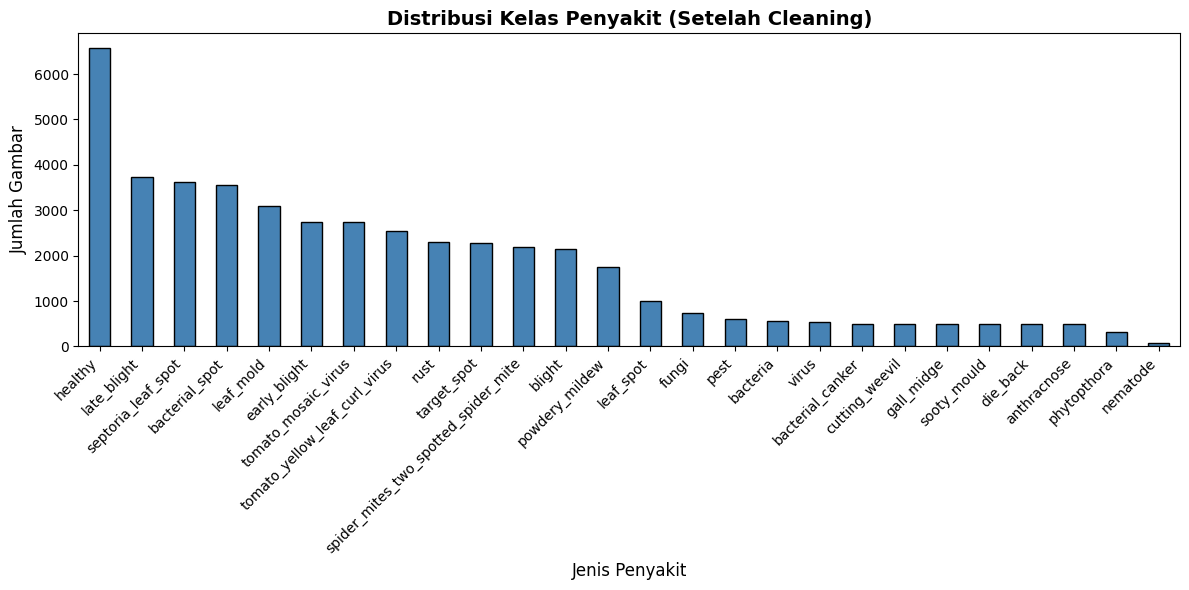

In [ ]:
# 1. Gunakan df_cleaned sesuai dengan tabel yang baru dibuat
class_counts = df_cleaned['disease'].value_counts()

print(class_counts)

# 2. Mengatur ukuran kanvas grafik agar lebih luas dan proporsional
plt.figure(figsize=(12, 6))

# 3. Membuat bar chart dengan warna yang lebih menarik
class_counts.plot(kind='bar', color='steelblue', edgecolor='black')

# 4. Menambahkan judul dan label sumbu
plt.title("Distribusi Kelas Penyakit (Setelah Cleaning)", fontsize=14, fontweight='bold')
plt.xlabel("Jenis Penyakit", fontsize=12)
plt.ylabel("Jumlah Gambar", fontsize=12)

# 5. Memiringkan teks nama penyakit di sumbu X agar mudah dibaca
plt.xticks(rotation=45, ha='right')

# 6. Mencegah ada bagian grafik yang terpotong
plt.tight_layout()
plt.show()

In [33]:
print("--- Distribusi Lokasi ---")
print(df_cleaned['location'].value_counts())

print("\n--- Rentang Waktu Dataset ---")
print("Dari:", df_cleaned['date'].min())
print("Sampai:", df_cleaned['date'].max())

--- Distribusi Lokasi ---
location
Sulawesi      11644
Sumatera      11480
Jawa          11468
Kalimantan    11463
Name: count, dtype: int64

--- Rentang Waktu Dataset ---
Dari: 2023-01-01 00:00:00
Sampai: 2024-12-01 00:00:00
